In [1]:
from pathlib import Path

_EXPORT = "comparison1_yolo26n_export"
_RUN = "comparison1_yolo26n"


def _repo_root_with_run() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / _EXPORT / "runs" / _RUN).is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Could not find {_EXPORT}/runs/{_RUN}; run the notebook from the repo root or Analysis/."
    )


BASE = str(_repo_root_with_run() / _EXPORT / "runs" / _RUN)


## **Part V: Multi-Version YOLO Comparison (YOLOv26n)**

### Experimental Settings

This is the first of three comparison models run as part of Part V. 
The goal is to compare YOLOv11n (baseline) against other YOLO versions trained under identical conditions to evaluate how architecture differences affect performance on the VisDrone dataset.

All settings were kept identical to the Part I baseline to ensure a fair comparison:

| Setting | Baseline (YOLOv11n) | Comparison 1 (YOLOv26n) |
|---|---|---|
| Dataset | VisDrone2019 | VisDrone2019 |
| Image Size | 640 | 640 |
| Batch Size | 16 | 16 |
| Max Epochs | 200 | 200 |
| Patience | 50 | 50 |
| **Model** | **YOLOv11n** | **YOLOv26n** |

The only difference is the model version. YOLOv26n is a newer architecture in the YOLO family and is being evaluated here to see whether architectural improvements in later versions translate to better performance on a multi-class drone detection task.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = f"{BASE}/results.csv"

df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

# final epoch metrics
final = df.iloc[-1]
print("=== Final Epoch Results ===")
print(f"mAP@50:        {final['metrics/mAP50(B)']:.4f}")
print(f"mAP@50-95:     {final['metrics/mAP50-95(B)']:.4f}")
print(f"Precision:     {final['metrics/precision(B)']:.4f}")
print(f"Recall:        {final['metrics/recall(B)']:.4f}")
print(f"Train Box Loss:{final['train/box_loss']:.4f}")
print(f"Val Box Loss:  {final['val/box_loss']:.4f}")

=== Final Epoch Results ===
mAP@50:        0.3491
mAP@50-95:     0.2006
Precision:     0.4640
Recall:        0.3430
Train Box Loss:1.8825
Val Box Loss:  1.8765


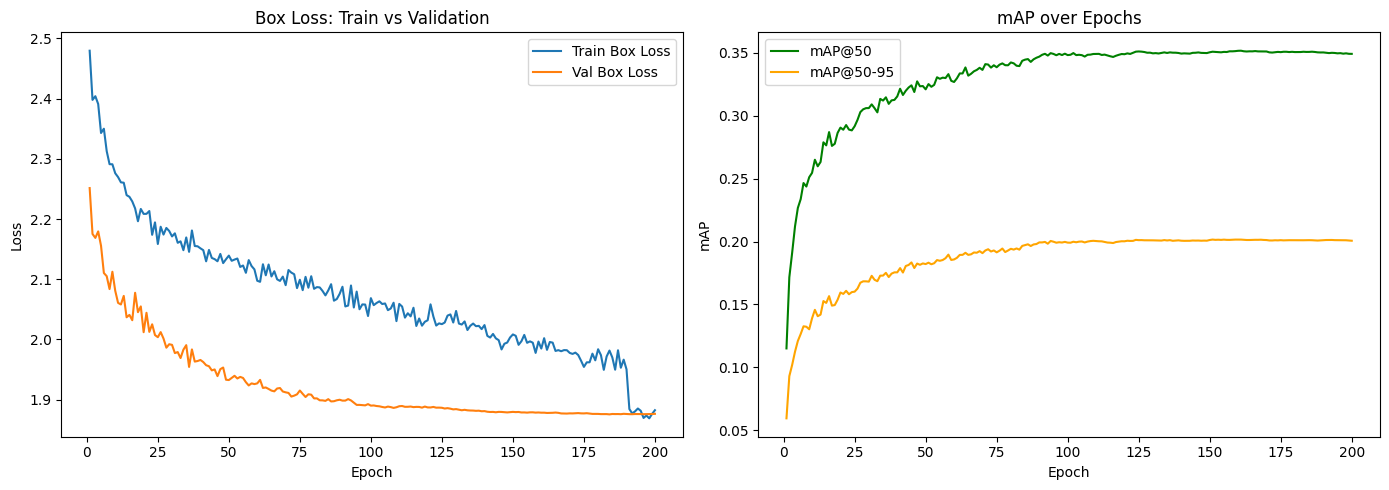

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
axes[0].set_title('Box Loss: Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# mAP curve
axes[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
axes[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='orange')
axes[1].set_title('mAP over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{BASE}/loss_map_curves.png", dpi=150)
plt.show()

In [4]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3491,0.2006,0.464,0.343


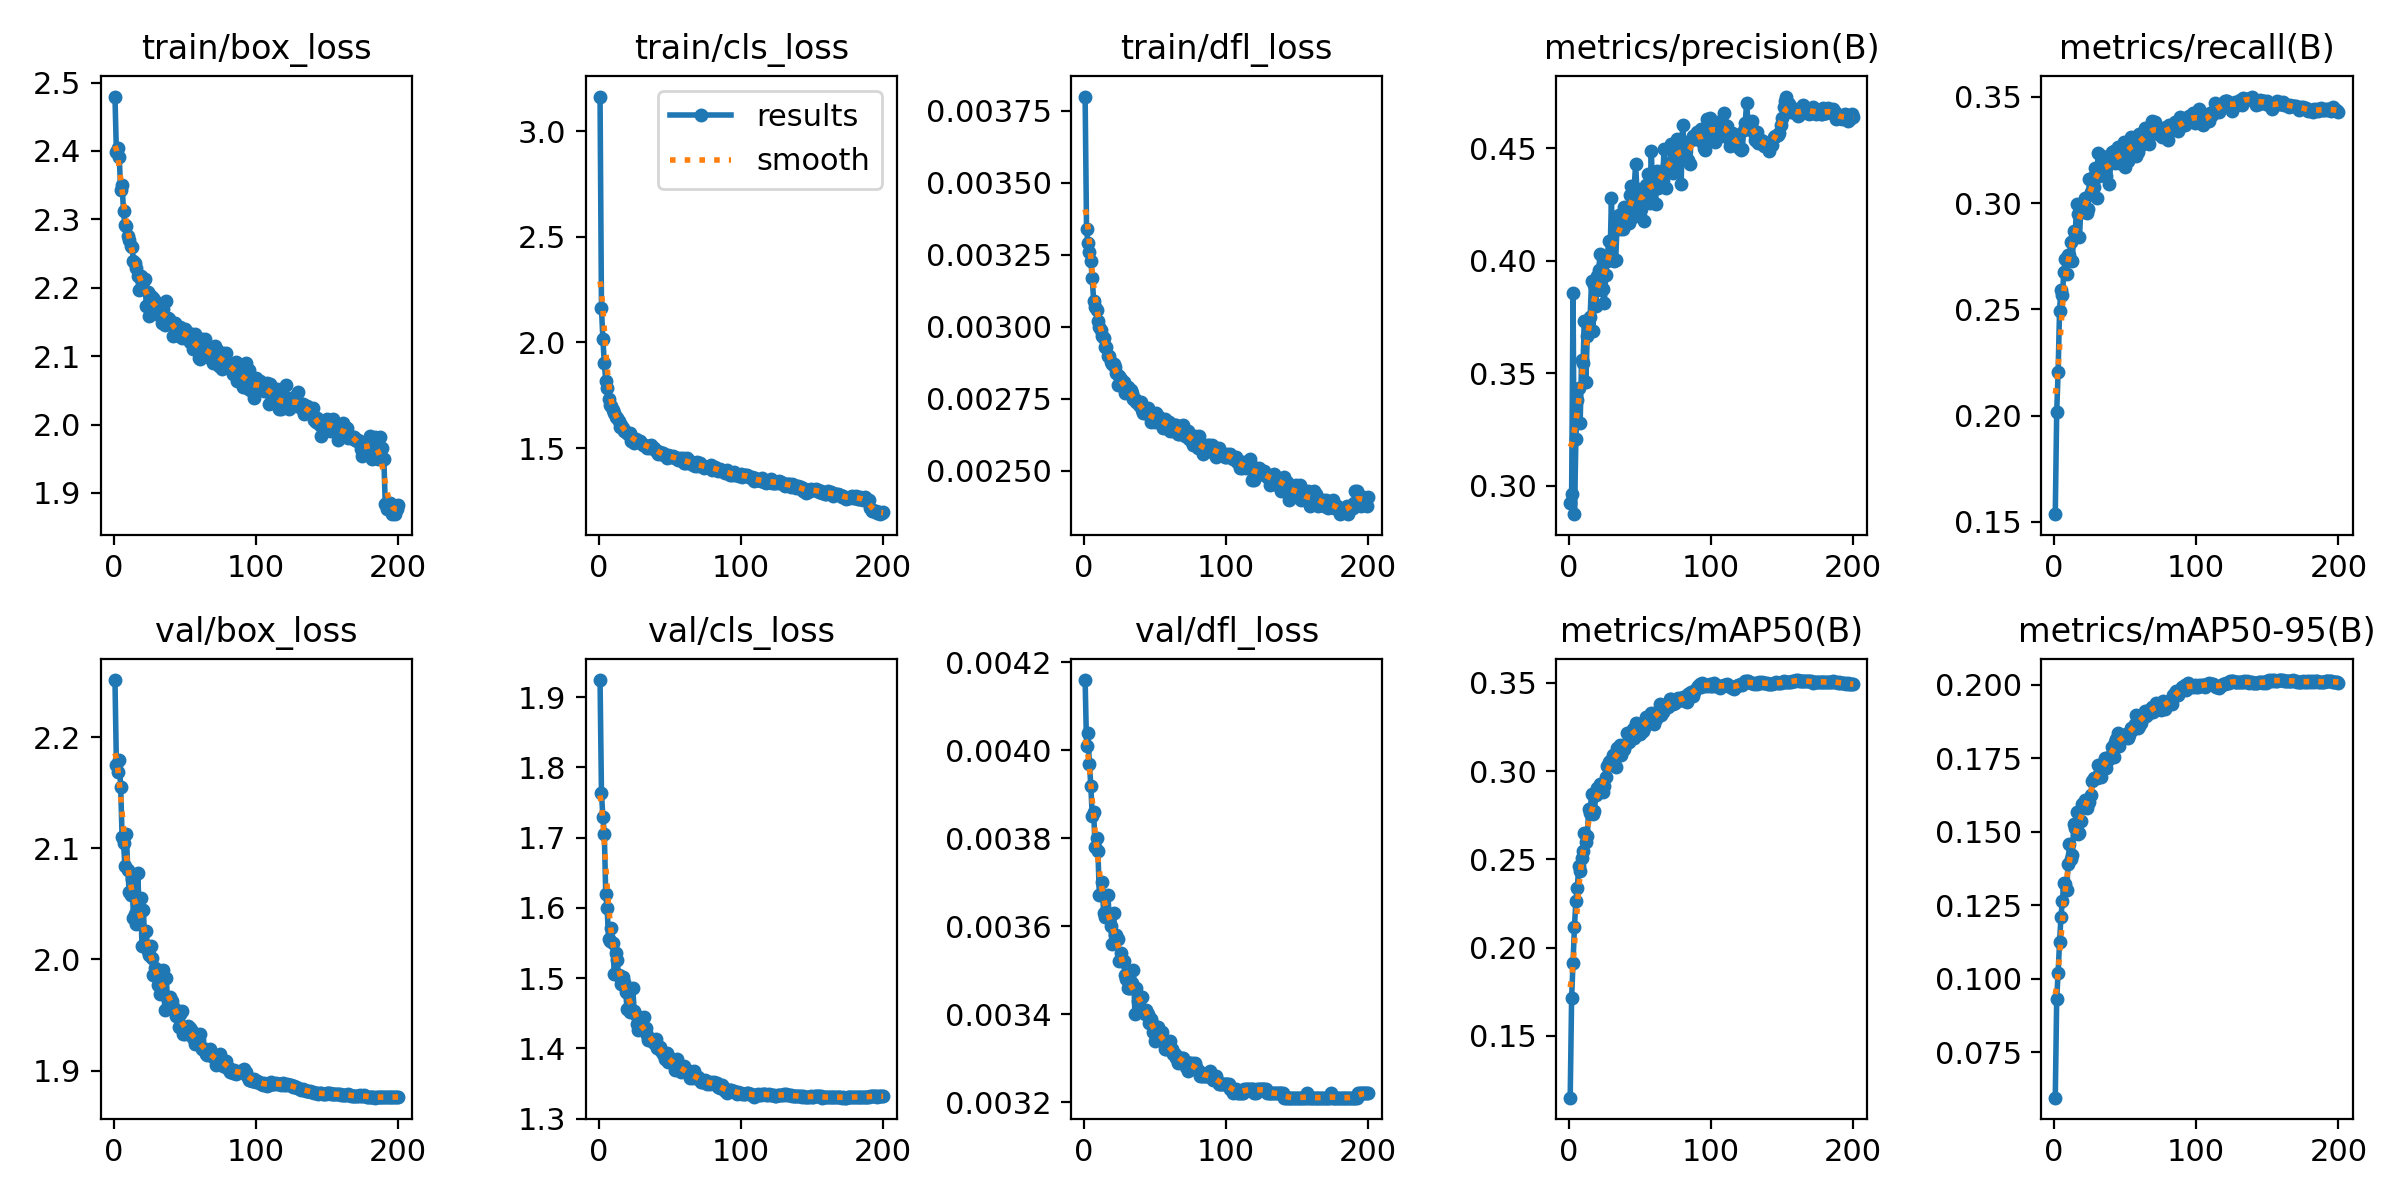

In [5]:
from IPython.display import Image, display
display(Image(f"{BASE}/results.png"))

### **Discussion**

**Note:** 200 epochs were set with a patience of 50 during training. The model ran the full 200 epochs, meaning early stopping did not trigger. This indicates the model continued to show improvement throughout training, unlike the baseline which stopped at epoch 129.

### 1. Training vs. Validation Loss

The loss curves above plot the **box loss** for both the training set and the validation set across all 200 epochs. The key observations are:

- Both curves descend steadily throughout training, indicating the model is consistently learning object detection features.
- The curves slow down after approximately epoch 100–120 but continue showing gradual improvement through to epoch 200.
- At the final epoch (epoch 200), the **training box loss is 1.8825** and the **validation box loss is 1.8765**, a gap of roughly **-0.006**.

The negative gap is a notable finding; the validation loss is very slightly lower than the training loss. 
This means the model is generalizing well and shows **no overfitting**, which is the opposite of what was observed in Part III with YOLOv11s.

### 2. Convergence Behavior

The model had **not fully converged** by epoch 200. Evidence:
- Early stopping did not trigger, meaning the model was still improving within the last 50 epochs.
- The mAP@50 stabilizes around **0.349** and mAP@50-95 around **0.201** by the end of training, but the curves suggest further training may have yielded marginal additional improvement.
- The loss values (1.88) are noticeably higher than those of YOLOv11n (1.39) at the same stage, which may suggest that YOLOv26n requires more epochs to converge on this dataset.

### 3. Results Curves (results.png)

The results.png panel shows all training and validation losses alongside precision, recall, mAP@50, and mAP@50-95 across all 200 epochs.

All three training losses decrease consistently throughout training without divergence, indicating stable optimization. 
The validation losses closely mirror the training losses throughout, consistent with the near-zero train/val gap, confirming that the model is not overfitting.

Precision stabilizes around **0.46**, consistent with the final reported value of 0.4640. 
Recall settles around **0.34**, which is slightly lower than the YOLOv11n baseline (0.3467). 
Both mAP curves show a steady upward trend throughout training that only begins to plateau near the end, reinforcing that the model had not fully converged by epoch 200. 
The gap between mAP@50 (0.3491) and mAP@50-95 (0.2006) is similar to the YOLOv11n baseline, suggesting comparable localization precision between the two architectures.

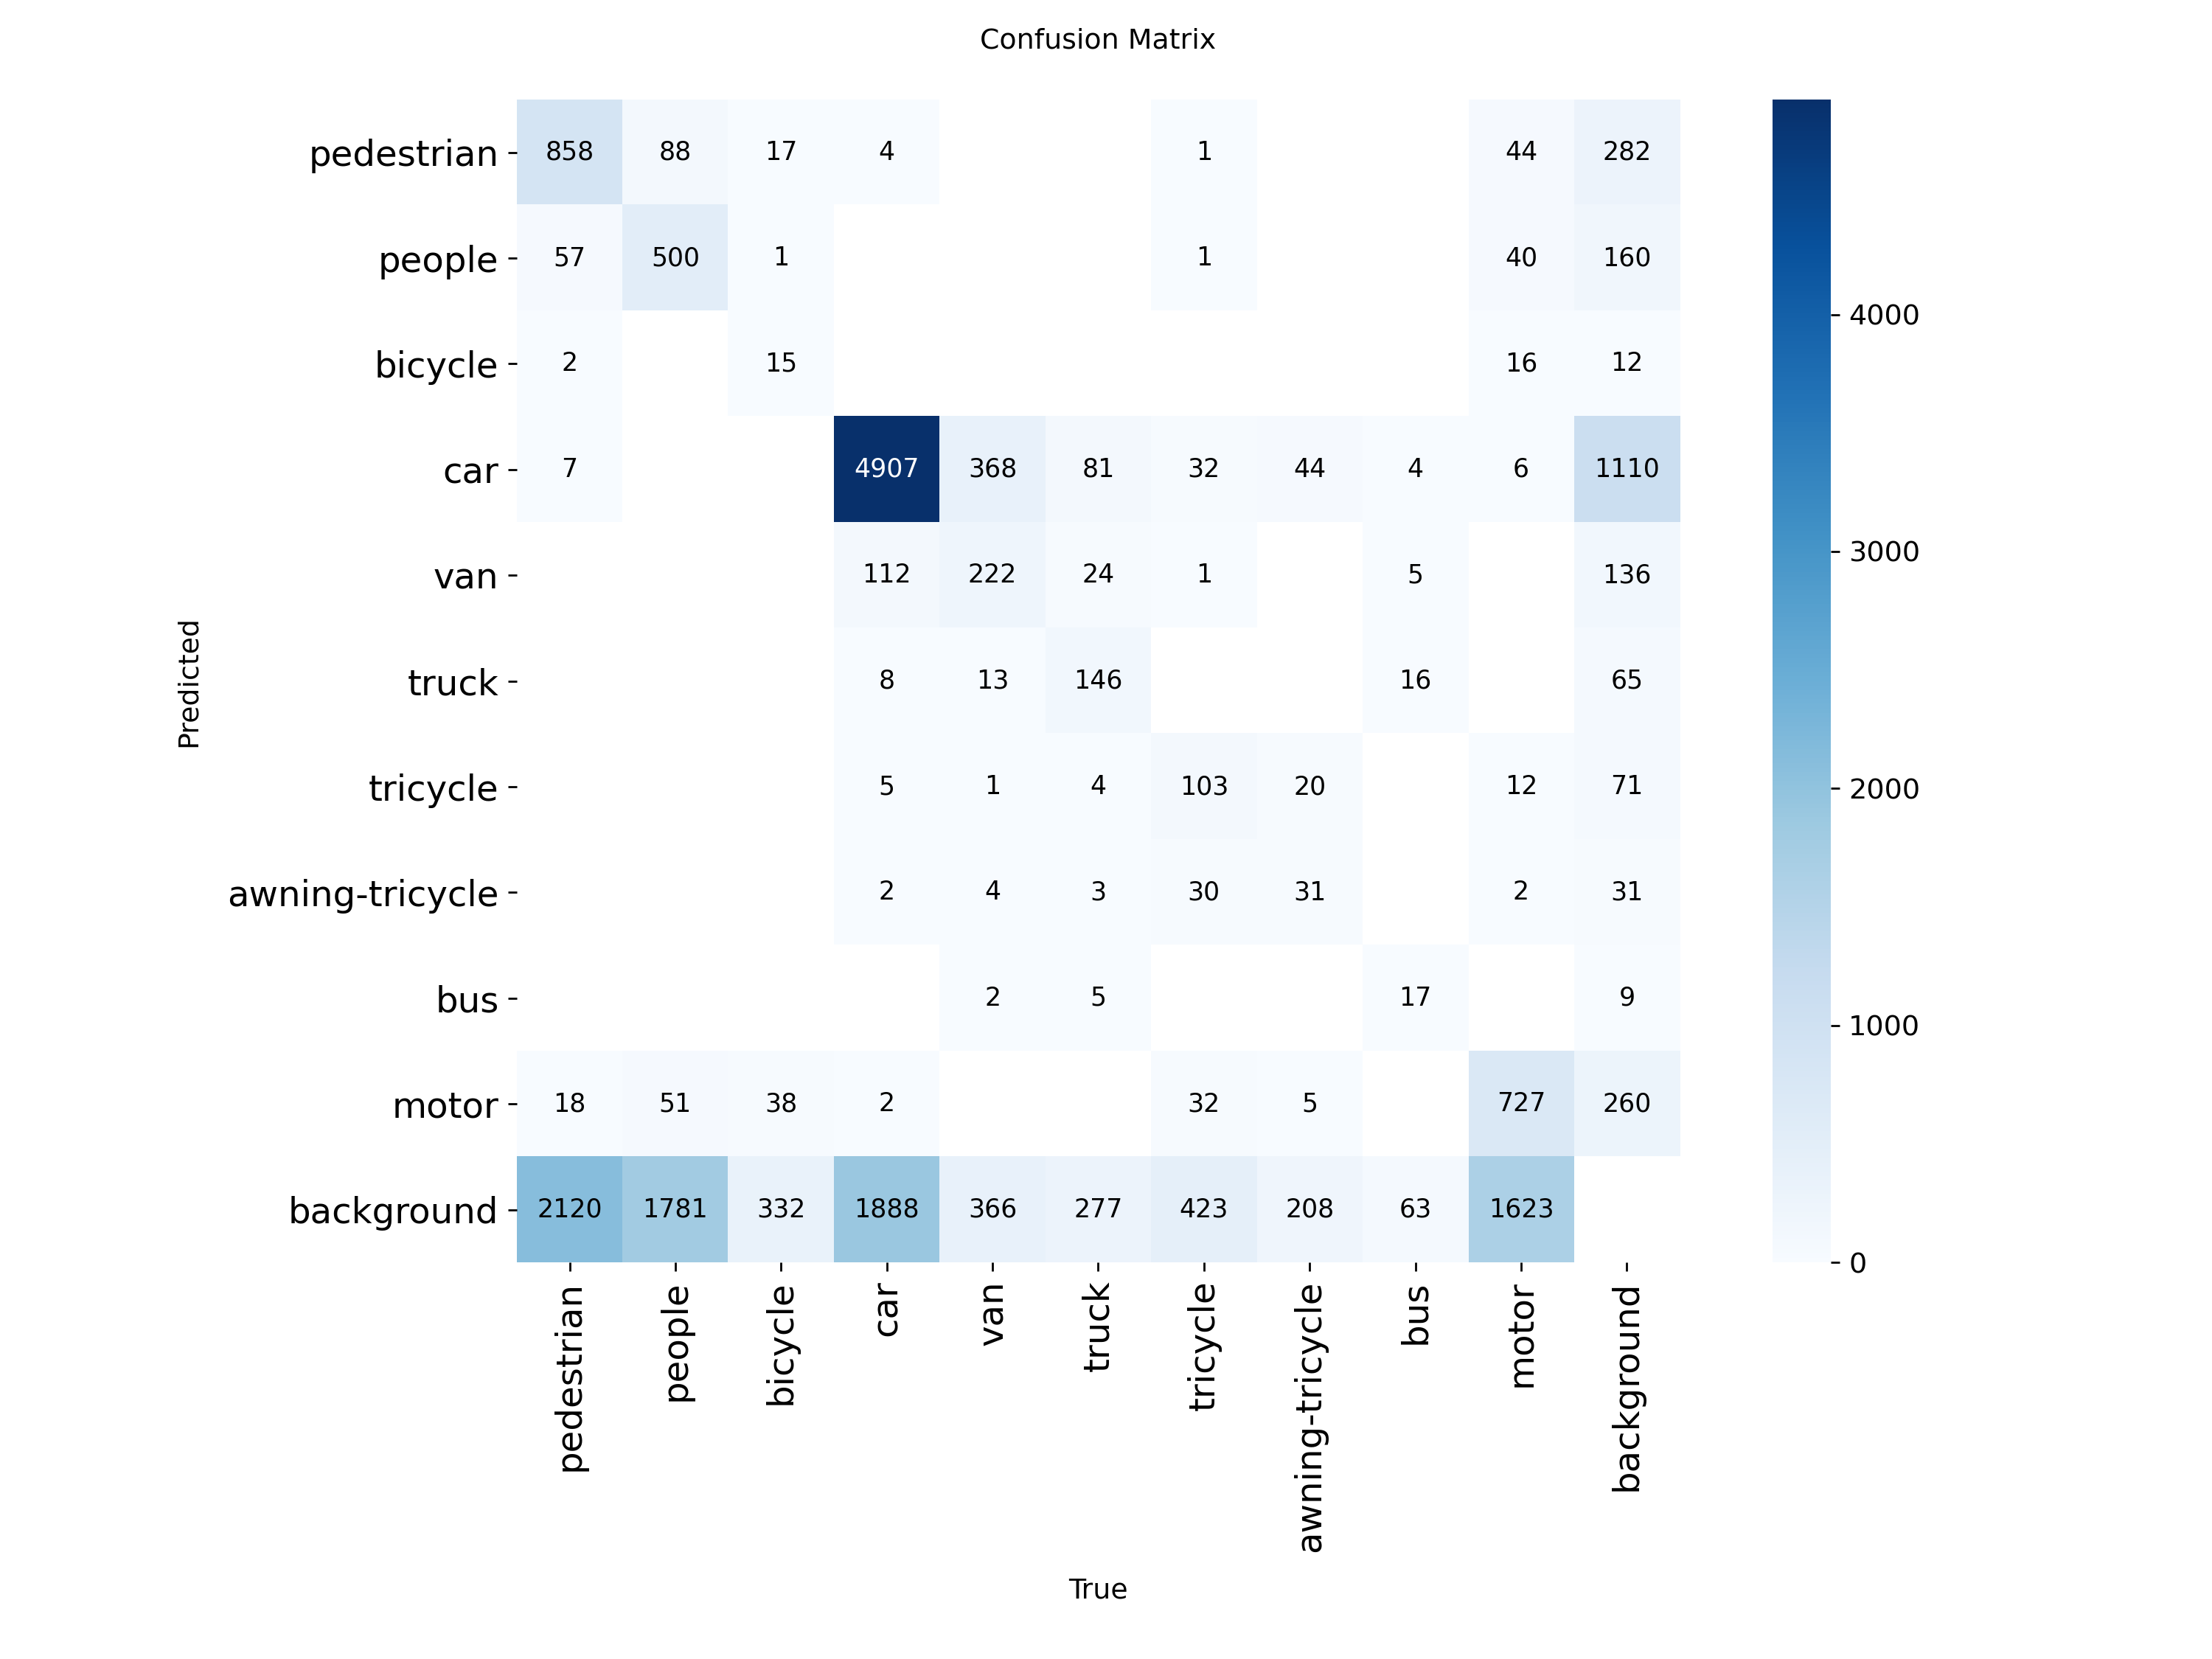

In [6]:
display(Image(f"{BASE}/confusion_matrix.png"))

### **Discussion**

### 4. Confusion Matrix

The confusion matrix shows detections across **all 10 classes**, consistent with previous runs on the same dataset. 
The overall detection pattern is broadly similar to YOLOv11n, with car remaining the dominant class and smaller objects performing weakest.

**Car:**
Car remains the strongest performing class, which is expected given its high instance count in the validation set. 
The model detects cars confidently with relatively few misclassifications.

**Pedestrian and People:**
Both pedestrian and people show similar detection patterns to the YOLOv11n baseline. 
Cross-class confusion between the two remains present due to their visual similarity, particularly at the small scales typical of drone imagery. 
The rate of false negatives for these classes is similar to the baseline, which is reflected in the comparable recall values.

**Bicycle, Tricycle, and Awning-Tricycle:**
These classes continue to show the weakest detection performance. 
They are small and infrequent objects that are difficult to detect at low resolution. 
YOLOv26n does not show a clear improvement over YOLOv11n for these classes, suggesting that the architecture change alone is not enough to overcome the dataset imbalance for rare classes.

**Bus and Van:**
Bus and van show similar detection performance to the baseline. 
Van is still occasionally confused with car or truck due to visual similarity in shape and size.

**Overall:**
The model still misses a large number of objects across most classes, labeling them as background. 
This is why recall (0.3430) is lower than precision (0.4640). 
The pattern is very similar to the YOLOv11n baseline, suggesting that switching to YOLOv26n alone does not significantly change the detection behavior on this dataset.

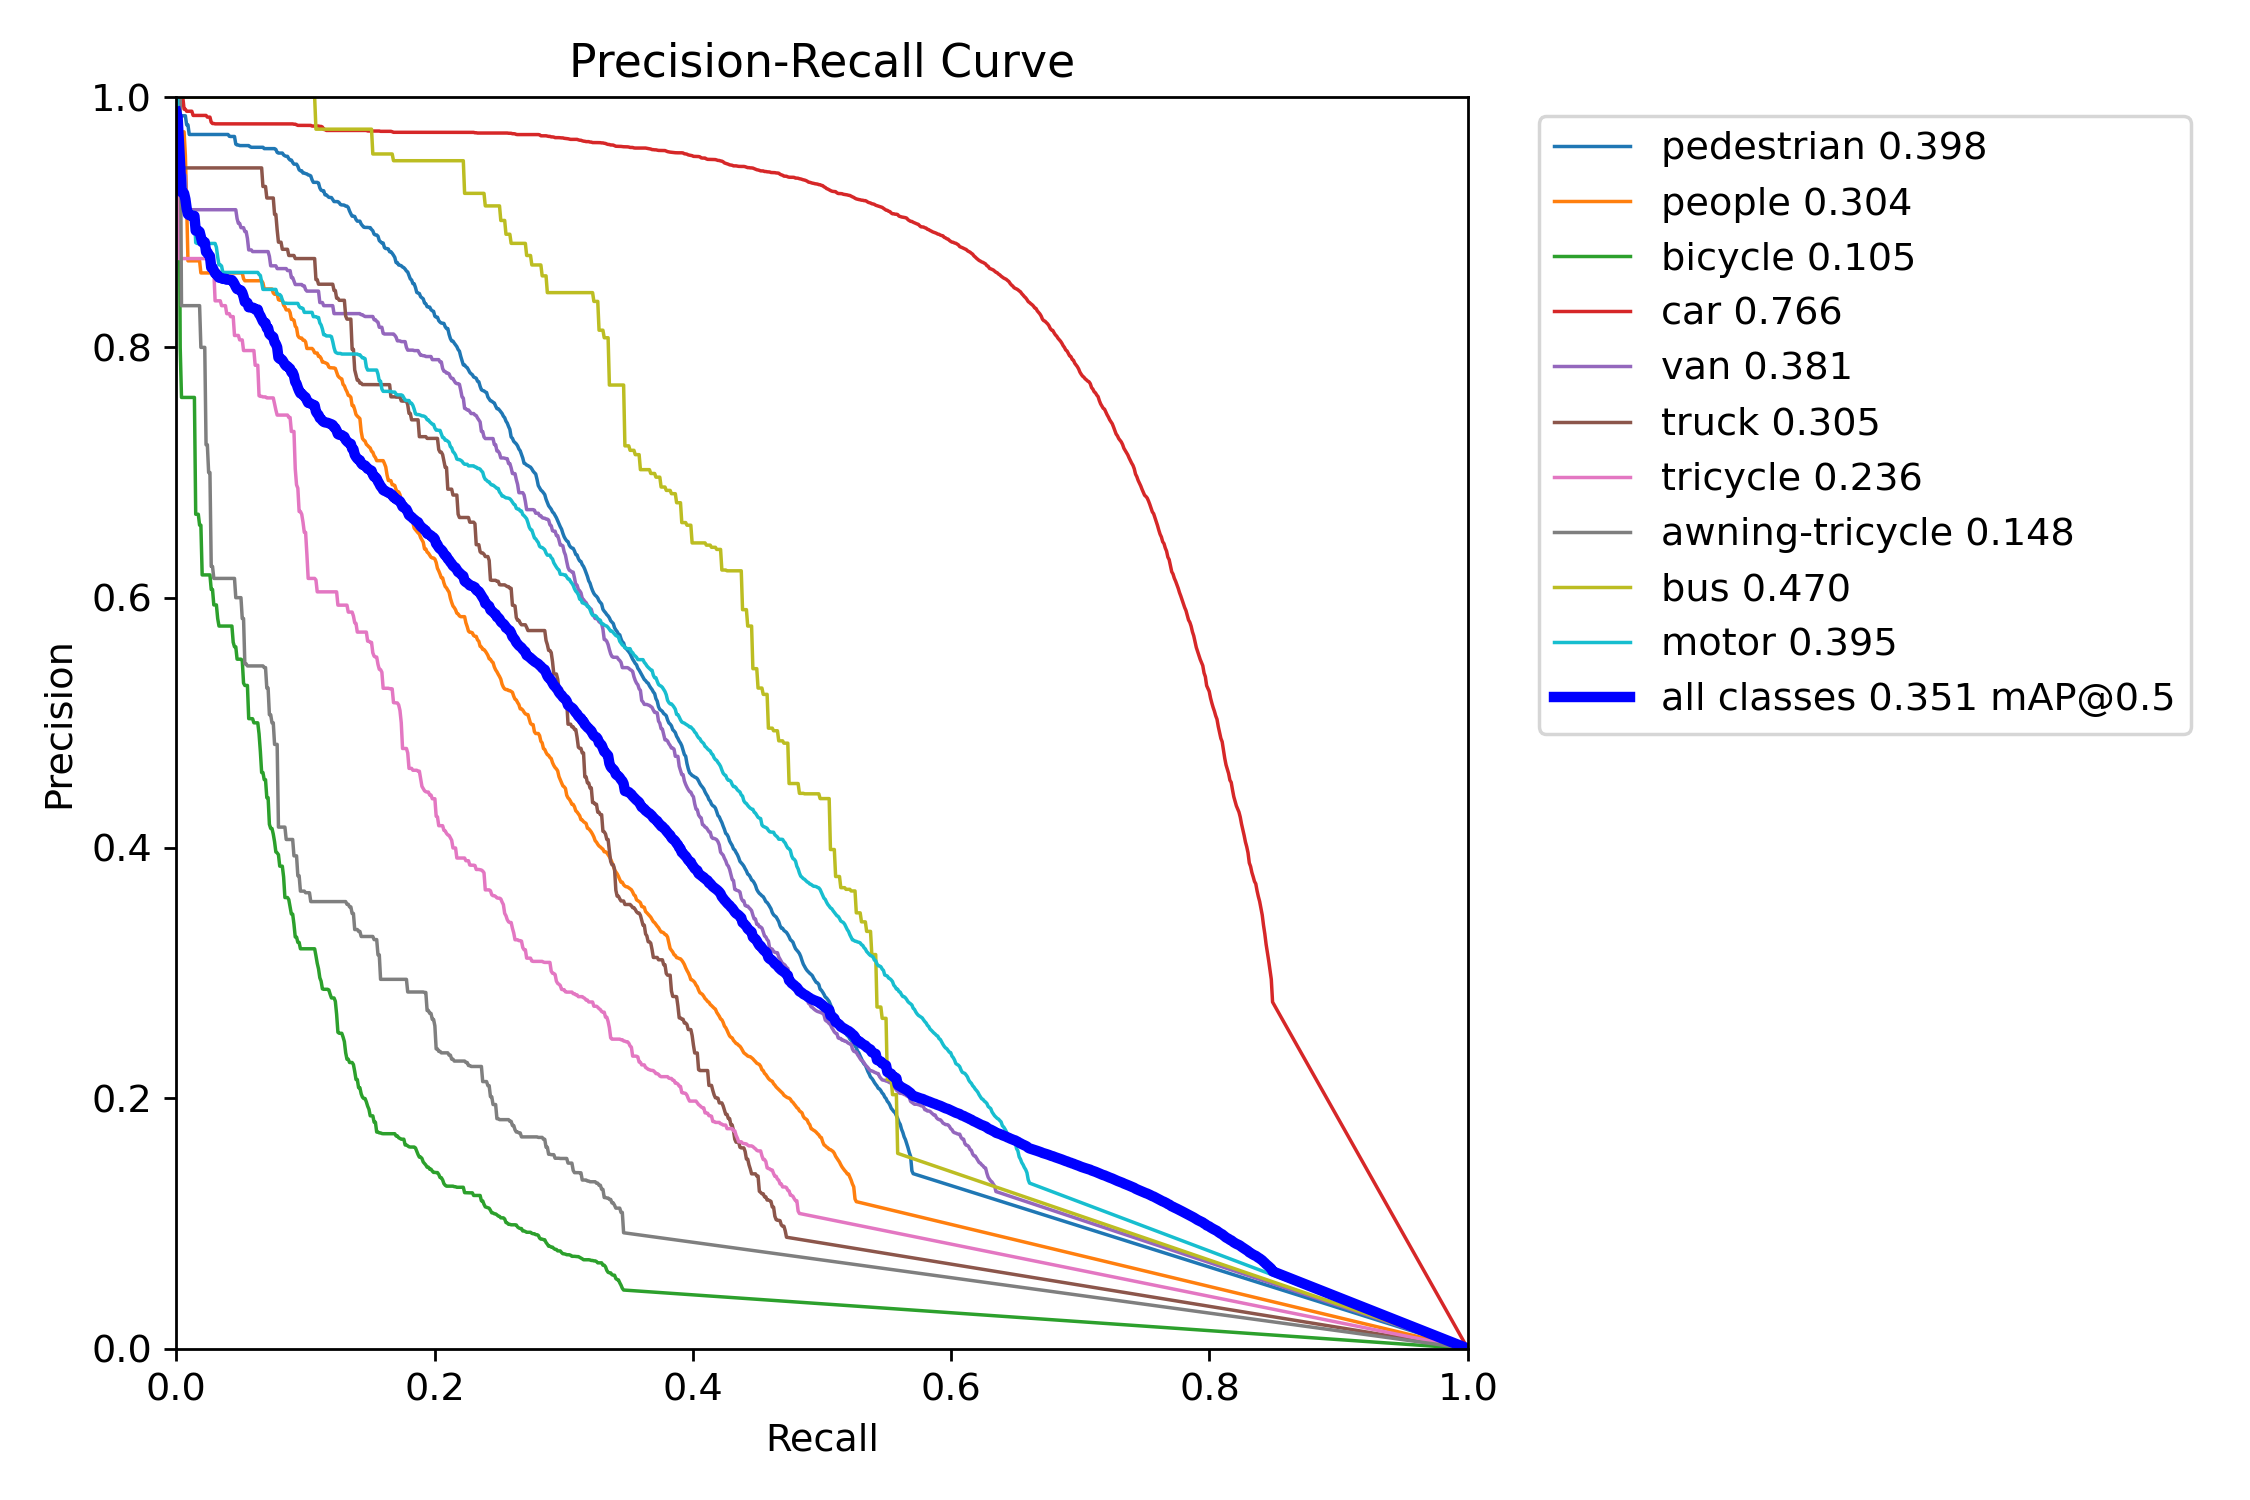

In [7]:
display(Image(f"{BASE}/BoxPR_curve.png"))

### 5. PR Curve (Precision Recall Curve)

The PR curve plots precision against recall at varying confidence thresholds for each class, with the area under each curve representing the per-class average precision.

**Car** has the strongest PR curve, maintaining high precision across a wide range of recall values. 
This is consistent with all previous runs on this dataset.

**Motor and Bus** show decent performance compared to the weaker classes, with precision staying fairly consistent at lower recall thresholds before starting to drop.

**Pedestrian and People** both show curves that start dropping in precision earlier than car and motor, reflecting the cross-class confusion between these two visually similar categories.

**Bicycle, Tricycle, and Awning-Tricycle** have the weakest curves, dropping steeply even at low recall values. 
These are small, infrequent objects that the model struggles to detect reliably. 
Even when the confidence threshold is lowered, the model ends up making a lot of wrong detections, meaning precision drops quickly.

The overall **mAP@50 of 0.3491** is very close to the YOLOv11n baseline (0.3494). 
Despite being a newer architecture, YOLOv26n does not outperform YOLOv11n on this dataset under identical training conditions, which may be partly explained by the fact that YOLOv26n had not fully converged by epoch 200.

### **Discussion Summary**

### 6. Overfitting Analysis

**No overfitting is observed** in this run. Evidence:
- The final training loss (1.8825) and validation loss (1.8765) are nearly identical, with a gap of approximately **-0.006**.
- The validation loss is very slightly lower than the training loss, which is the opposite of overfitting.
- The two curves track each other very closely throughout all 200 epochs.

This is a positive finding in terms of generalization, but the higher absolute loss values (1.88 vs 1.39 for YOLOv11n) suggest that YOLOv26n may need more epochs or a different learning rate schedule to converge to a lower loss on this dataset.

### 7. Underfitting Analysis

There are **mild signs of underfitting or incomplete convergence**. Evidence:
- The model ran the full 200 epochs without early stopping triggering, meaning it was still improving at the end of training.
- The final loss values are higher than those of YOLOv11n at the same epoch count.
- The mAP curves were still gradually rising near epoch 200, suggesting the model had not yet reached its performance ceiling.

This does not mean the model failed to learn; it achieved a mAP@50 of 0.3491 which is comparable to the baseline. 
However, given more training time, YOLOv26n may have continued to improve.

### 8. Causes: Architecture and Training Duration

**Architecture Differences:**

YOLOv26n is a newer architecture compared to YOLOv11n. Newer YOLO versions often introduce changes to the backbone, neck, and detection head that can affect how quickly the model converges and how well it generalizes. 
The fact that YOLOv26n shows no overfitting while YOLOv11n shows mild overfitting suggests that YOLOv26n may have stronger built-in regularization or a different parameter distribution that makes it less prone to memorizing training data.

**Training Duration:**

The most likely reason for the comparable rather than superior performance of YOLOv26n is that 200 epochs may not be enough for this architecture to fully converge on the VisDrone dataset. 
YOLOv11n converged around epoch 129, while YOLOv26n was still improving at epoch 200. 
Given more training time, YOLOv26n may outperform YOLOv11n, but within the constraints of this experiment the results are essentially equal.

In [8]:
summary = {
    "Model": ["YOLOv11n"],
    "Epochs": [len(df)],
    "mAP@50": [round(final['metrics/mAP50(B)'], 4)],
    "mAP@50-95": [round(final['metrics/mAP50-95(B)'], 4)],
    "Precision": [round(final['metrics/precision(B)'], 4)],
    "Recall": [round(final['metrics/recall(B)'], 4)],
}
pd.DataFrame(summary)

,Model,Epochs,mAP@50,mAP@50-95,Precision,Recall
0,YOLOv11n,200,0.3491,0.2006,0.464,0.343


**Summary Table:**

| Observation | What Was Seen | Possible Reason |
|---|---|---|
| No overfitting | Training and validation loss nearly identical (gap ~-0.006) | YOLOv26n architecture may have stronger built-in regularization |
| Model ran full 200 epochs | Early stopping did not trigger | YOLOv26n requires more epochs to converge on this dataset |
| Similar mAP to baseline (0.3491 vs 0.3494) | No significant improvement over YOLOv11n | Model had not fully converged; more epochs may show improvement |
| Lower recall than baseline (0.3430 vs 0.3467) | Slightly fewer true detections | Similar class imbalance challenges affect both architectures equally |

### **Part V Note**

This is the first of three comparison models in Part V. 
The results show that YOLOv26n achieves comparable performance to YOLOv11n on the VisDrone dataset under identical training conditions, with the key difference being that YOLOv26n shows no overfitting but also had not fully converged by epoch 200. 
Results from all three comparison models will be compiled into a final structured comparison table in the Part V summary notebook.